# Viability- and feedback-oriented sustainability model

This notebook implements a reusable solver for the slide model

$$
\tau_R \frac{dR}{dt} = G(R) - D(R) + E,
\qquad
\tau_I \frac{dI}{dt} = c\,u - I,
\qquad
\varepsilon = \frac{\tau_I}{\tau_R}.
$$

The structure is generic, but now the time-scale mismatch is explicit:

- `\tau_R`: regeneration or system-adjustment time scale
- `\tau_I`: implementation time scale
- `\varepsilon = \tau_I / \tau_R`: governance-to-system time-scale ratio
- `G(R)`: regeneration
- `D(R, I, t)`: depletion
- `u(R, I, t)`: governance decision
- `E(R, I, u, t)`: managed intervention

The worked example below uses a state-feedback policy so we can see how delay, compliance, intervention, and time-scale mismatch shape viability.

In [1]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve().parent
IMG = ROOT / "images"
IMG.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#111827",
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "axes.titlesize": 13,
    "font.size": 12,
})


def save_figure(fig, filename):
    image_path = IMG / filename
    fig.savefig(image_path, dpi=220, bbox_inches="tight")
    print(f"saved {image_path}")
    plt.close(fig)


def rk4(f, y0, t):
    y0 = np.atleast_1d(y0).astype(float)
    y = np.zeros((len(t), len(y0)), dtype=float)
    y[0] = y0
    for i in range(len(t) - 1):
        h = t[i + 1] - t[i]
        k1 = np.asarray(f(t[i], y[i]), dtype=float)
        k2 = np.asarray(f(t[i] + 0.5 * h, y[i] + 0.5 * h * k1), dtype=float)
        k3 = np.asarray(f(t[i] + 0.5 * h, y[i] + 0.5 * h * k2), dtype=float)
        k4 = np.asarray(f(t[i] + h, y[i] + h * k3), dtype=float)
        y[i + 1] = y[i] + h * (k1 + 2 * k2 + 2 * k3 + k4) / 6.0
    return y


def logistic_regeneration(r, rho=0.7, capacity=1.0):
    return rho * r * (1.0 - r / capacity)


def clipped_linear_policy(r, target=0.65, gain=2.2, base=0.15, u_max=1.0):
    shortfall = np.maximum(target - r, 0.0)
    return np.clip(base + gain * shortfall, 0.0, u_max)


In [2]:
@dataclass
class SustainabilityModel:
    regen_rate: float = 0.7
    capacity: float = 1.0
    tau_R: float = 12.0
    demand_pressure: float = 0.38
    overload_sensitivity: float = 0.85
    intervention_strength: float = 0.9
    compliance: float = 0.78
    tau_I: float = 5.0
    viable_min: float = 0.3
    target: float = 0.65
    control_gain: float = 2.2
    base_effort: float = 0.15
    u_max: float = 1.0

    @property
    def epsilon(self):
        return self.tau_I / self.tau_R

    def G(self, r):
        return logistic_regeneration(r, rho=self.regen_rate, capacity=self.capacity)

    def D(self, r, i, _u, _t):
        stress = np.maximum(self.target - r, 0.0)
        return self.demand_pressure * r + self.overload_sensitivity * stress * r

    def policy(self, r, _i, _t, mode="feedback"):
        if mode == "open_loop":
            return self.base_effort
        return clipped_linear_policy(
            r,
            target=self.target,
            gain=self.control_gain,
            base=self.base_effort,
            u_max=self.u_max,
        )

    def E(self, r, i, u, _t):
        return self.intervention_strength * i * (1.0 - r / self.capacity)

    def rhs(self, t, y, mode="feedback"):
        r, i = y
        r = np.clip(r, 0.0, self.capacity)
        u = self.policy(r, i, t, mode=mode)
        g = self.G(r)
        d = self.D(r, i, u, t)
        e = self.E(r, i, u, t)
        dr = (g - d + e) / self.tau_R
        di = (self.compliance * u - i) / self.tau_I
        return np.array([dr, di], dtype=float)

    def simulate(self, t, y0, mode="feedback"):
        states = rk4(lambda tt, yy: self.rhs(tt, yy, mode=mode), y0=y0, t=t)
        resource = np.clip(states[:, 0], 0.0, self.capacity)
        impact = np.clip(states[:, 1], 0.0, None)
        decision = np.array([self.policy(r, i, tt, mode=mode) for tt, (r, i) in zip(t, states)])
        regen = np.array([self.G(r) for r in resource])
        deplete = np.array([self.D(r, i, u, tt) for tt, r, i, u in zip(t, resource, impact, decision)])
        support = np.array([self.E(r, i, u, tt) for tt, r, i, u in zip(t, resource, impact, decision)])
        viable = resource >= self.viable_min
        return {
            "t": t,
            "R": resource,
            "I": impact,
            "u": decision,
            "G": regen,
            "D": deplete,
            "E": support,
            "viable": viable,
        }


def summarize_run(name, result, model):
    first_violation = np.flatnonzero(~result["viable"])
    if len(first_violation) == 0:
        status = "viable for the full horizon"
    else:
        status = f"leaves viability at t={result['t'][first_violation[0]]:.2f}"
    print(
        f"{name}: R_min={result['R'].min():.3f}, R_final={result['R'][-1]:.3f}, "
        f"I_final={result['I'][-1]:.3f}, {status}"
    )

tau_R=4.00, tau_I=6.00, epsilon=1.50
open_loop: R_min=0.155, R_final=0.155, I_final=0.062, leaves viability at t=16.80
feedback: R_min=0.518, R_final=0.568, I_final=0.303, viable for the full horizon


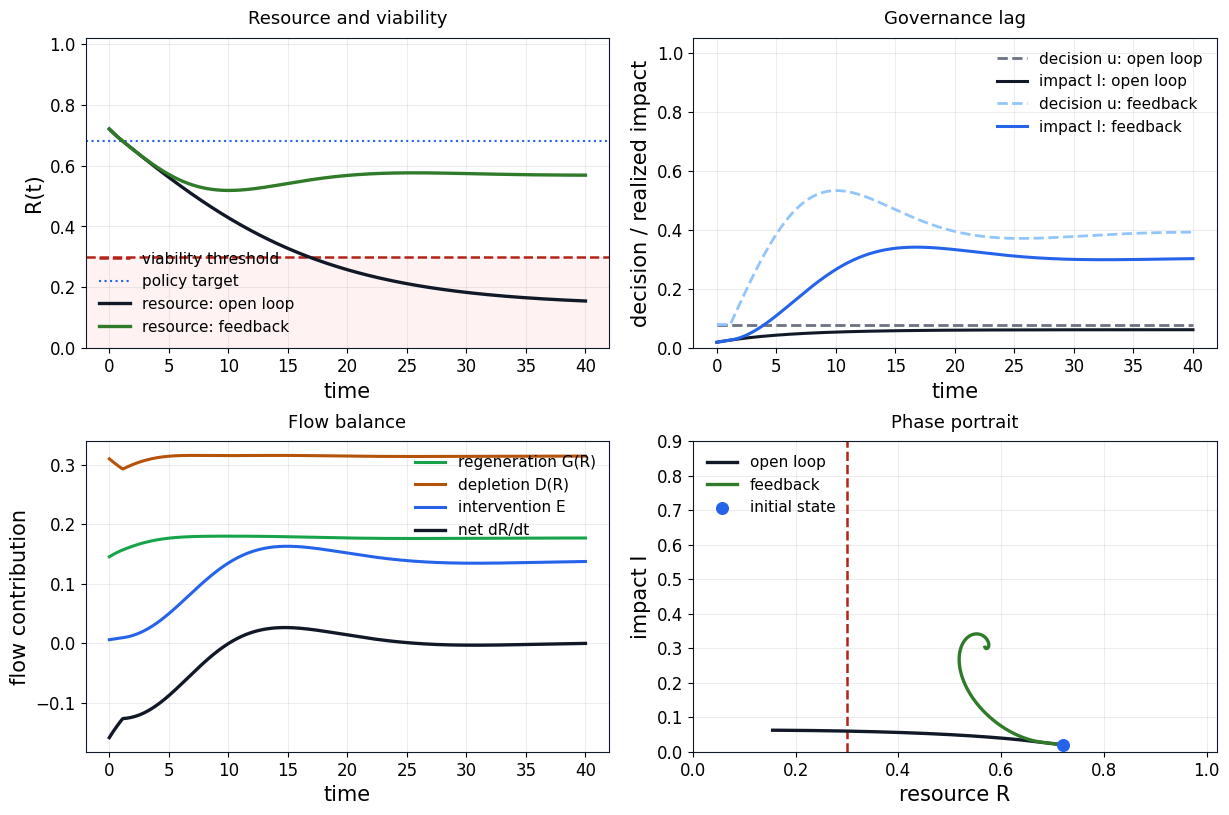

In [3]:
#| label: fig-viability-feedback-solver
#| fig-cap: "Generic viability model with explicit time-scale separation: open-loop governance can lose the viable region, while feedback governance stabilizes the resource by increasing decisions as the resource approaches the threshold. The key parameter is the ratio epsilon = tau_I / tau_R."
#| fig-alt: "Four-panel plot showing resource, decision and realized impact, flow balance, and a phase portrait for open-loop versus feedback governance."

model = SustainabilityModel(
    tau_R=4.0,
    regen_rate=0.72,
    demand_pressure=0.43,
    overload_sensitivity=1.10,
    intervention_strength=1.05,
    compliance=0.78,
    tau_I=6.0,
    viable_min=0.30,
    target=0.68,
    control_gain=2.8,
    base_effort=0.08,
    u_max=1.00,
)

t = np.linspace(0.0, 40.0, 801)
y0 = np.array([0.72, 0.02])

open_loop = model.simulate(t, y0, mode="open_loop")
feedback = model.simulate(t, y0, mode="feedback")

print(f"tau_R={model.tau_R:.2f}, tau_I={model.tau_I:.2f}, epsilon={model.epsilon:.2f}")
summarize_run("open_loop", open_loop, model)
summarize_run("feedback", feedback, model)

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5))
fig.subplots_adjust(left=0.08, right=0.985, bottom=0.08, top=0.92, wspace=0.16, hspace=0.30)

ax = axes[0, 0]
ax.axhspan(0.0, model.viable_min, color="#fef2f2", alpha=0.95, zorder=0)
ax.axhline(model.viable_min, color="#b42318", lw=1.8, ls="--", label="viability threshold")
ax.axhline(model.target, color="#2563eb", lw=1.5, ls=":", label="policy target")
ax.plot(t, open_loop["R"], color="#111827", lw=2.4, label="resource: open loop")
ax.plot(t, feedback["R"], color="#2f7b29", lw=2.4, label="resource: feedback")
ax.set_title("Resource and viability", pad=10)
ax.set_xlabel("time")
ax.set_ylabel("R(t)")
ax.set_ylim(0.0, 1.02)
ax.grid(alpha=0.22)
ax.legend(frameon=False, loc="lower left")

ax = axes[0, 1]
ax.plot(t, open_loop["u"], color="#6b7280", lw=2.0, ls="--", label="decision u: open loop")
ax.plot(t, open_loop["I"], color="#111827", lw=2.2, label="impact I: open loop")
ax.plot(t, feedback["u"], color="#93c5fd", lw=2.0, ls="--", label="decision u: feedback")
ax.plot(t, feedback["I"], color="#2563eb", lw=2.2, label="impact I: feedback")
ax.set_title("Governance lag", pad=10)
ax.set_xlabel("time")
ax.set_ylabel("decision / realized impact")
ax.set_ylim(0.0, 1.05)
ax.grid(alpha=0.22)
ax.legend(frameon=False, loc="upper right")

ax = axes[1, 0]
ax.plot(t, feedback["G"], color="#16a34a", lw=2.2, label="regeneration G(R)")
ax.plot(t, feedback["D"], color="#b45309", lw=2.2, label="depletion D(R)")
ax.plot(t, feedback["E"], color="#2563eb", lw=2.2, label="intervention E")
ax.plot(t, feedback["G"] - feedback["D"] + feedback["E"], color="#111827", lw=2.4, label="net dR/dt")
ax.set_title("Flow balance", pad=10)
ax.set_xlabel("time")
ax.set_ylabel("flow contribution")
ax.grid(alpha=0.22)
ax.legend(frameon=False, loc="upper right")

ax = axes[1, 1]
ax.axvline(model.viable_min, color="#b42318", lw=1.8, ls="--")
ax.plot(open_loop["R"], open_loop["I"], color="#111827", lw=2.4, label="open loop")
ax.plot(feedback["R"], feedback["I"], color="#2f7b29", lw=2.4, label="feedback")
ax.scatter([y0[0]], [y0[1]], color="#2563eb", s=70, zorder=4, label="initial state")
ax.set_title("Phase portrait", pad=10)
ax.set_xlabel("resource R")
ax.set_ylabel("impact I")
ax.set_xlim(0.0, 1.02)
ax.set_ylim(0.0, 0.9)
ax.grid(alpha=0.22)
ax.legend(frameon=False, loc="upper left")

#save_figure(fig, "viability_feedback_solver.png")

In [4]:
# Small hooks for reuse in later experiments.
model

SustainabilityModel(regen_rate=0.72, capacity=1.0, tau_R=4.0, demand_pressure=0.43, overload_sensitivity=1.1, intervention_strength=1.05, compliance=0.78, tau_I=6.0, viable_min=0.3, target=0.68, control_gain=2.8, base_effort=0.08, u_max=1.0)